# Hand Report
    Manually draw a neural network having 3 hidden layers for classifying images of 10 English digits. 
    Manually draw Forward Propagation Computation Graph
    Manually draw Backpropagation Computation Graph
    Manually derive equations for updating weights of each hidden layer  and output layer.
    Train model using the MNIST digit dataset with the help of Tensorflow's tf.GradientTape().
    Compare the performance of the model trained by tf.GradientTape() with Tensorflow's model.fit()

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import umap

In [ ]:
def preprocess_dataset(x, y):
    x = tf.expand_dims(x, -1)
    x = tf.image.resize(x, [224, 224])
    x = tf.image.grayscale_to_rgb(x)
    x = x / 255.0
    y = to_categorical(y, num_classes=10)
    return x, y


In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train[:2000]
y_train = y_train[:2000]
x_test = x_test[:1000]
y_test = y_test[:1000]

x_train, y_train = preprocess_dataset(x_train, y_train)
x_test, y_test = preprocess_dataset(x_test, y_test)

In [ ]:
input = Input((224,224,3))
x = Flatten()(input)
x = Dense(3, activation='relu')(x)
x = Dense(2, activation='relu')(x)
x = Dense(3, activation='relu')(x)
output = Dense(10, activation='softmax')(x)

model = Model(inputs=input, outputs=output)


# Training the model using the tf.GradientTape()

In [ ]:
loss_fn = tf.keras.losses.CategoricalCrossentropy()
optimizer = tf.keras.optimizers.AdamW()

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(1000).batch(32)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(32)


In [ ]:
train_loss, train_acc = [], []
for epoch in range(50):
    print(f"\nEpoch {epoch+1}")

    for x_batch, y_batch in train_ds:
        with tf.GradientTape() as tape:
            logits = model(x_batch, training=True)
            loss = loss_fn(y_batch, logits)
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        acc = tf.keras.metrics.categorical_accuracy(y_batch, logits)
        train_loss.append(loss.numpy())
        train_acc.extend(acc.numpy())

    print(f"Train Loss: {np.mean(train_loss):.4f}, Train Accuracy: {np.mean(train_acc):.4f}")



Epoch 1
Train Loss: 2.1730, Train Accuracy: 0.1585

Epoch 2
Train Loss: 2.1336, Train Accuracy: 0.1725

Epoch 3
Train Loss: 2.1117, Train Accuracy: 0.1780

Epoch 4
Train Loss: 2.0953, Train Accuracy: 0.1807

Epoch 5
Train Loss: 2.0799, Train Accuracy: 0.1843

Epoch 6
Train Loss: 2.0681, Train Accuracy: 0.1864

Epoch 7
Train Loss: 2.0579, Train Accuracy: 0.1884

Epoch 8
Train Loss: 2.0479, Train Accuracy: 0.1902

Epoch 9
Train Loss: 2.0382, Train Accuracy: 0.1913

Epoch 10
Train Loss: 2.0292, Train Accuracy: 0.1926

Epoch 11
Train Loss: 2.0218, Train Accuracy: 0.1938

Epoch 12
Train Loss: 2.0163, Train Accuracy: 0.1943

Epoch 13
Train Loss: 2.0097, Train Accuracy: 0.1945

Epoch 14
Train Loss: 2.0028, Train Accuracy: 0.1957

Epoch 15
Train Loss: 1.9966, Train Accuracy: 0.1972

Epoch 16
Train Loss: 1.9904, Train Accuracy: 0.1988

Epoch 17
Train Loss: 1.9850, Train Accuracy: 0.1998

Epoch 18
Train Loss: 1.9796, Train Accuracy: 0.2007

Epoch 19
Train Loss: 1.9748, Train Accuracy: 0.2022

E

In [ ]:
test_loss, test_acc = [], []

for x_batch, y_batch in test_ds:
    logits = model(x_batch, training=False)
    loss = loss_fn(y_batch, logits)
    acc = tf.keras.metrics.categorical_accuracy(y_batch, logits)

    test_loss.append(loss.numpy())
    test_acc.extend(acc.numpy())

print(f"\nTest Loss: {np.mean(test_loss):.4f}, Test Accuracy: {np.mean(test_acc):.4f}")




Test Loss: 1.9843, Test Accuracy: 0.2030


In [ ]:
y_pred_probs = model.predict(x_test)

y_pred_classes = np.argmax(y_pred_probs, axis=1)

y_true_classes = np.argmax(y_test, axis=1)

accuracy = np.mean(y_pred_classes == y_true_classes)
print(f"Prediction Accuracy: {accuracy:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Prediction Accuracy: 0.2030


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=50, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.2463 - loss: 1.7968 - val_accuracy: 0.1950 - val_loss: 1.9828
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2383 - loss: 1.7806 - val_accuracy: 0.2070 - val_loss: 1.9976
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.2341 - loss: 1.7980 - val_accuracy: 0.2020 - val_loss: 2.0217
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.2436 - loss: 1.7775 - val_accuracy: 0.1850 - val_loss: 2.0336
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2469 - loss: 1.7901 - val_accuracy: 0.2000 - val_loss: 2.0216
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2506 - loss: 1.7949 - val_accuracy: 0.1880 - val_loss: 2.0063
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.2657 - loss: 1.7798 - val_accuracy: 0.2020 - val_loss: 2.0333
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2492 - loss: 1.7885 - val_accuracy: 0.1950 - v

In [ ]:
# --- Predict on test data ---
y_pred_probs = model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# --- Evaluate test accuracy ---
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2093 - loss: 2.1356
Test Accuracy: 0.2120


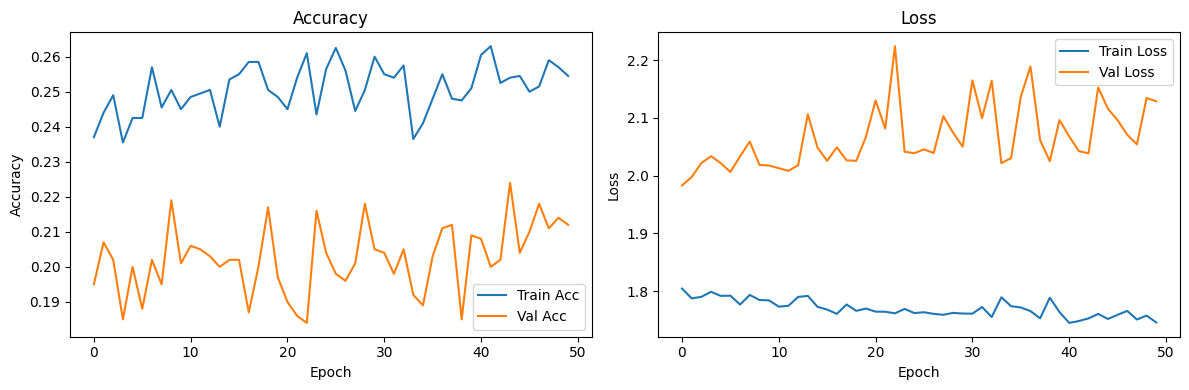

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
